In [1]:
import os 
import pandas as pd
import seaborn as sns

OASIS_PATH = os.path.join("..", "data", "raw", "oasis_combined_synthetic.csv")

def load_oasis_data(oasis_path = OASIS_PATH):
    return pd.read_csv(oasis_path)

oasis = load_oasis_data()
oasis.head()

,Subject.ID,MRI.ID,Group,Visit,MR.Delay,Gender,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Risk.Group
0,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457.0,M,R,88,14,2.0,30,0.0,2004.0,0.681,0.876,Nondemented
1,OAS2_0004,OAS2_0004_MR2,Nondemented,2,538.0,F,R,90,18,3.0,27,0.0,1200.0,0.718,1.462,Nondemented
2,OAS2_0005,OAS2_0005_MR3,Nondemented,3,1603.0,M,R,85,12,4.0,30,0.0,1699.0,0.705,1.033,Nondemented
3,OAS2_0008,OAS2_0008_MR2,Nondemented,2,742.0,F,R,95,14,2.0,29,0.0,1257.0,0.703,1.396,Nondemented
4,OAS2_0012,OAS2_0012_MR3,Nondemented,3,1598.0,F,R,83,16,2.0,29,0.0,1323.0,0.718,1.327,Nondemented


In [2]:
oasis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject.ID  5150 non-null   object 
 1   MRI.ID      5150 non-null   object 
 2   Group       5150 non-null   object 
 3   Visit       5150 non-null   int64  
 4   MR.Delay    5150 non-null   float64
 5   Gender      5150 non-null   object 
 6   Hand        5150 non-null   object 
 7   Age         5150 non-null   int64  
 8   EDUC        5150 non-null   int64  
 9   SES         4860 non-null   float64
 10  MMSE        5150 non-null   int64  
 11  CDR         5150 non-null   float64
 12  eTIV        5150 non-null   float64
 13  nWBV        5150 non-null   float64
 14  ASF         5150 non-null   float64
 15  Risk.Group  5150 non-null   object 
dtypes: float64(6), int64(4), object(6)
memory usage: 643.9+ KB


"Risk.Group" é a nossa variável target, mas está na forma categórica, precisa ser numérica para a divisão de grupos de teste e treinamento.
"Gender" também é categórica e pode ser transformada em numérica sem problemas antes da divisão.
"Subject.ID", "MRI.ID", "Visit" e "MR.Delay" são identificadores, eles não afetam o modelo, então dá pra excluir.
"Hand" só possui um valor, "R". Como todas as inserções tem esse valor, é possível excluir essa coluna.
"Group" é equivalente à coluna da variável target, então dá pra excluir também.

In [3]:
#fazendo cópia da tabela para não mexer na original
oasis_prepared = oasis.copy()

#fazendo mapping para transformar variável target categórica em numérica
mapeamento_target = {
    'Nondemented': 0,
    'Risk': 1
}

oasis_prepared['Risk.Group'] = oasis_prepared['Risk.Group'].map(mapeamento_target)
oasis_prepared['Risk.Group'].value_counts()



Risk.Group
1    2578
0    2572
Name: count, dtype: int64

In [4]:
#deletando colunas com informações irrelevantes 
oasis_prepared.drop(['Subject.ID', 'MRI.ID', 'Hand', 'MR.Delay', 'Visit', 'Group'], axis=1, inplace=True)

In [5]:
#criando coluna numérica para "Gender"
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(drop= 'if_binary', sparse_output=False)
encoded_data = enc.fit_transform(oasis_prepared[['Gender']])

#adicionando nova coluna e excluindo a anterior
oasis_prepared['Gender.Num'] = encoded_data
oasis_prepared.drop('Gender', axis=1, inplace=True)
oasis_prepared.head()

,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Risk.Group,Gender.Num
0,88,14,2.0,30,0.0,2004.0,0.681,0.876,0,1.0
1,90,18,3.0,27,0.0,1200.0,0.718,1.462,0,0.0
2,85,12,4.0,30,0.0,1699.0,0.705,1.033,0,1.0
3,95,14,2.0,29,0.0,1257.0,0.703,1.396,0,0.0
4,83,16,2.0,29,0.0,1323.0,0.718,1.327,0,0.0


In [6]:
oasis_prepared.describe()

,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Risk.Group,Gender.Num
count,5150.000000,5150.000000,4860.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000
mean,77.301748,14.577476,2.538683,27.401165,0.287767,1479.394200,0.729277,1.202564,0.500583,0.415146
std,7.727656,2.883798,1.061955,2.777961,0.329205,178.887823,0.036160,0.139941,0.500048,0.492795
min,61.000000,6.000000,1.000000,17.000000,0.000000,713.755491,0.599343,0.700329,0.000000,0.000000
25%,72.000000,13.000000,2.000000,26.000000,0.000000,1363.381739,0.705010,1.109567,0.000000,0.000000
50%,77.000000,15.000000,3.000000,28.000000,0.000000,1477.868899,0.728119,1.203290,1.000000,0.000000
75%,83.000000,17.000000,3.000000,30.000000,0.500000,1598.813342,0.753036,1.293484,1.000000,1.000000
max,97.000000,23.000000,5.000000,30.000000,1.000000,2070.262668,0.876903,1.830943,1.000000,1.000000


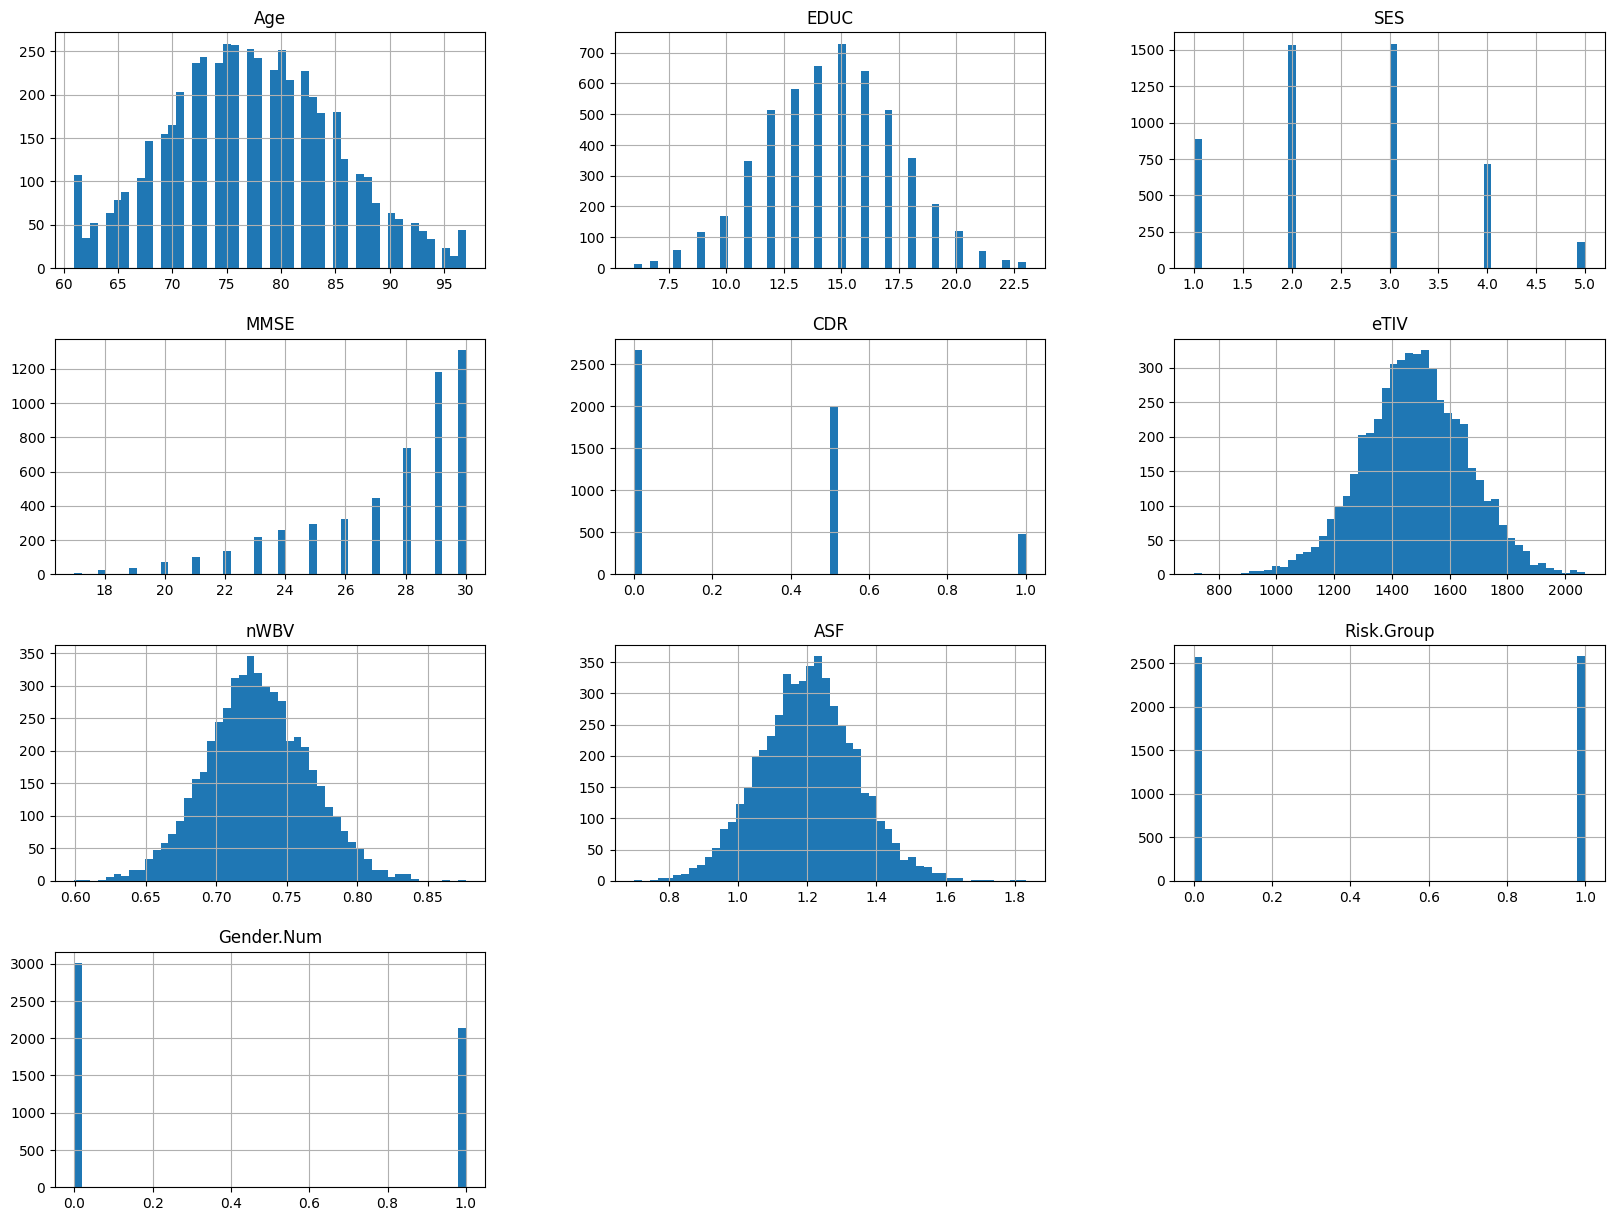

In [7]:
import matplotlib.pyplot as plt
oasis_prepared.hist(bins=50, figsize=(20,15))
plt.show()

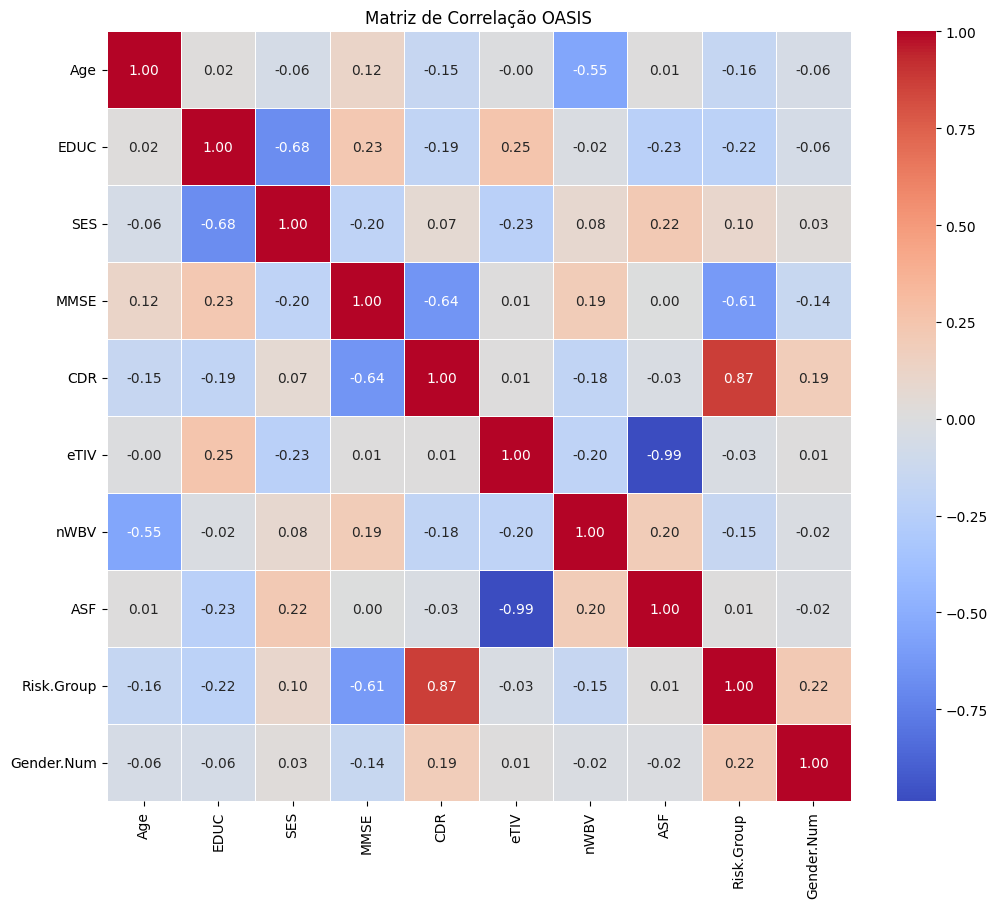

In [8]:
#construindo matriz de correlação com o dataset para analisar variáveis relacionadas
matriz_correlacao = oasis_prepared.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10}, linewidths=0.5)
plt.title("Matriz de Correlação OASIS")
plt.show()

O ASF e o eTIV são altamente correlacionáveis, assim é necessário tirar um deles do dataset. Por conta da maior facilidade na obtenção do eTIV, será retirado o ASF. O CDR também não pode ser deixado, pois ele é uma variável que carrega informações sobre o target.

In [9]:
oasis_prepared.drop(['ASF', 'CDR'], axis=1, inplace=True)
oasis_prepared.head()

,Age,EDUC,SES,MMSE,eTIV,nWBV,Risk.Group,Gender.Num
0,88,14,2.0,30,2004.0,0.681,0,1.0
1,90,18,3.0,27,1200.0,0.718,0,0.0
2,85,12,4.0,30,1699.0,0.705,0,1.0
3,95,14,2.0,29,1257.0,0.703,0,0.0
4,83,16,2.0,29,1323.0,0.718,0,0.0


In [10]:
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
oasis_prepared.to_csv(OASIS_PREPARED_PATH, index=False)